# Análisis de riesgo crediticio. Modelo de clasificación de clientes.

#### El objetivo es entender qué características separan a un "buen pagador" de uno con "riesgo de impago".

# Importación y primer vistazo a los datos.

In [1]:
# Importamos todas las librerías que utilizaremos.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve
from sklearn.preprocessing import StandardScaler

In [2]:
# Cargamos la base de datos
# Fue obtenida de: https://www.kaggle.com/c/GiveMeSomeCredit/data.

df = pd.read_csv("data/cs-training.csv")

In [3]:
# Eliminamos el índice basura (repetido).

df = df.drop(columns=["Unnamed: 0"])

In [4]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [6]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [7]:
# ¿Hay valores nulos?

df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [8]:
df.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [9]:
# La variable objetivo es SeriousDlqin2yrs
# 0 es si no hubo problemas. 1 es si hubo problemas con el pago del crédito.

x = df["SeriousDlqin2yrs"].value_counts()

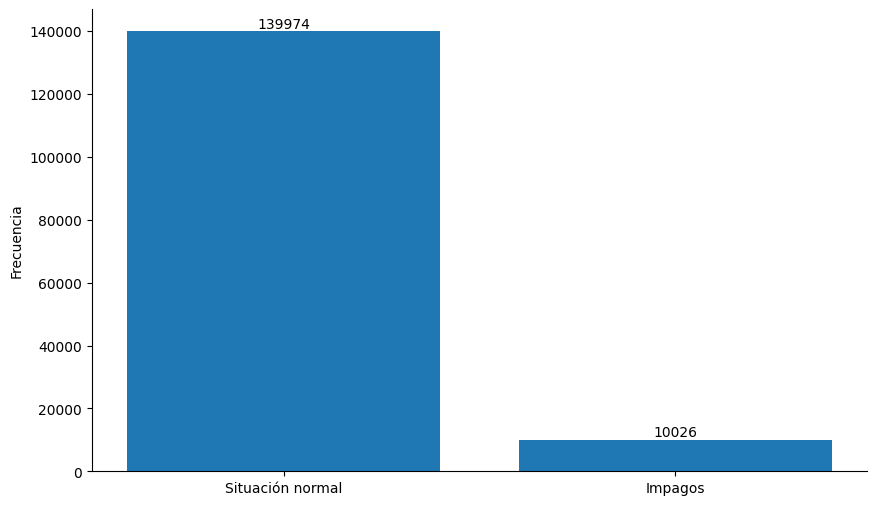

In [10]:
# El dataset está claramente desbalanceado, porque hay muchísimos más casos de la variable de interés de tipo 0 que de tipo 1.
# Para mostrar este desbalance vemos a continuación.

fig, ax = plt.subplots(figsize=(10, 6))
barras = ax.bar(["Situación normal", "Impagos"], [x[0], x[1]])
#ax.set_title("Situación crediticia", fontsize=14, fontweight="bold")
ax.set_ylabel("Frecuencia")
ax.bar_label(barras, padding=0)

# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("images/Situación_crediticia.png", bbox_inches="tight", dpi=300)
plt.show()

# Limpieza de datos.

In [11]:
# Vemos los valores nulos.

df.isnull().sum().sort_values(ascending=False)

MonthlyIncome                           29731
NumberOfDependents                       3924
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
dtype: int64

In [12]:
# ¿Qué hacemos con los valores nulos? Los reemplazamos por la mediana.
# ¿Por qué no por la media? Porque la media está sesgada hacia los valores extremos, la mediana representa mejor los datos centrales.
# Los valores medianos son:

print(df["MonthlyIncome"].median())
print(df["MonthlyIncome"].mean())
print(df["NumberOfDependents"].median())
print(df["NumberOfDependents"].mean())

5400.0
6670.221237392844
0.0
0.7572222678605657


In [13]:
df["MonthlyIncome"] = df["MonthlyIncome"].fillna(df["MonthlyIncome"].median())
df["NumberOfDependents"] = df["NumberOfDependents"].fillna(df["NumberOfDependents"].median())

In [14]:
# Ahora chequeamos y vemos que no tenemos más nulos

df.isnull().sum().sort_values(ascending=False)

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

In [15]:
# Buscamos valores raros. Especialmente en variables que con certeza conocemos qué rangos pueden tomar, por ejemplo: age.

# Las edades = 0 no tienen sentido.
# Los ratios de deuda enormes tampoco.

df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.418455e+03,8.452760,0.265973,1.018240,0.240387,0.737413
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.289040e+04,5.145951,4.169304,1.129771,4.155179,1.107021
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [16]:
# Procedemos a hacer una limpieza.

# El balance total de crédito es un porcentaje, por lo que no puede ser mayor a 1.
df = df[df["RevolvingUtilizationOfUnsecuredLines"] <= 1]

#Se eliminan los datos con edades no realistas.
df= df[df["age"] >= 18]

# El número de veces que una persona entró en impago en los últimos 30 días no puede ser 98. Fijamos un máximo de 10.
# Vemos que este número no tiene sentido ni para quienes entran en morosidad.
df[df["SeriousDlqin2yrs"] == 1]["NumberOfTime30-59DaysPastDueNotWorse"].describe()
df = df[df["NumberOfTime30-59DaysPastDueNotWorse"] <= 10]

# El ratio de deuda tampoco puede ser tan grande. La deuda sobre el inreso no debe ser 329664%. La limitamos a 5 veces el ingreso.
df = df[df["DebtRatio"] <= 5]

# El ingreso mensual es una variable que puede tomar valores muy altos por lo que no la tocaremos.
# El número de créditos abiertos en simultáneo es de 58, no parece irreal, por lo que dejamos esa variable sin tocar, sin embargo hace un poco de ruido.

# El número de veces que una persona entró en demora de pago por 90 días es raro que sea 17 veces. Borramos todo lo que sea más de 10.
df = df[df["NumberOfTimes90DaysLate"] <= 10] 

# El número de créditos hipotecarios no puede ser 32. Todo lo que sea mayor a 5 le pondremos el valor 5.
df["NumberRealEstateLoansOrLines"] = df["NumberRealEstateLoansOrLines"].clip(upper=5)

# El número de veces de morosidad intermedia máximo está en 11 por lo que no tocamos esa variable.

# El número de dependientes está sospechosamente alto en el máximo. Todo lo que sea mayor a 5 lo fijamos en 5.
df["NumberOfDependents"] = df["NumberOfDependents"].clip(upper=5)

In [17]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,117362.000000,117362.000000,117362.000000,117362.000000,117362.000000,1.173620e+05,117362.000000,117362.000000,117362.000000,117362.000000,117362.000000
mean,0.061613,0.313496,51.743989,0.239660,0.372655,6.808494e+03,8.719321,0.077785,1.028399,0.058290,0.829527
std,0.240452,0.337581,14.621149,0.678547,0.441280,1.450887e+04,5.205872,0.424905,1.034136,0.306737,1.125134
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.031289,41.000000,0.000000,0.134990,3.554250e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.162531,51.000000,0.000000,0.288663,5.416000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.540140,62.000000,0.000000,0.469318,8.300000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,1.000000,105.000000,10.000000,5.000000,3.008750e+06,57.000000,10.000000,5.000000,11.000000,5.000000


In [18]:
# De esta forma pasamos de tener:
# 150.000 ---> 117.362 datos.
# Una reducción importante pero la calidad de los datos es mejor.

# Visualización de datos.

In [19]:
# Primero buscaremos las primeras señales. Se busca encontrar cualquier tipo de relación a priori entre "impagos" y el estado de las demás variables.


<Figure size 1200x600 with 0 Axes>

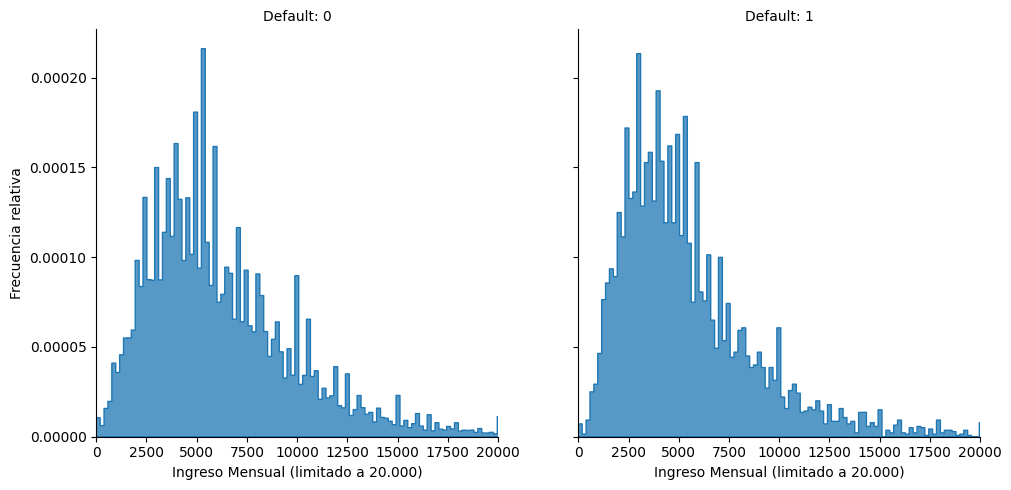

In [20]:
# Creamos el gráfico
plt.figure(figsize=(12, 6))

# Usamos 'hue' para separar por la columna de impago
g = sns.displot(data=df, x='MonthlyIncome', stat="density", common_norm=False, col='SeriousDlqin2yrs', kde=False, element="step")

# Limitamos el eje X si tienes ingresos muy altos (outliers) para que se vea bien
plt.xlim(0, 20000) 

g.set_axis_labels("Ingreso Mensual (limitado a 20.000)", "Frecuencia relativa")
g.set_titles("Default: {col_name}")
#g.fig.suptitle("Distribución de Ingresos: Buenos Pagadores vs Impagos", y=1.05, fontsize=14, fontweight="bold")
g.fig.subplots_adjust(wspace=0.2)

g.savefig("images/distribucion_ingreso.png", dpi=300, bbox_inches="tight")
plt.show()

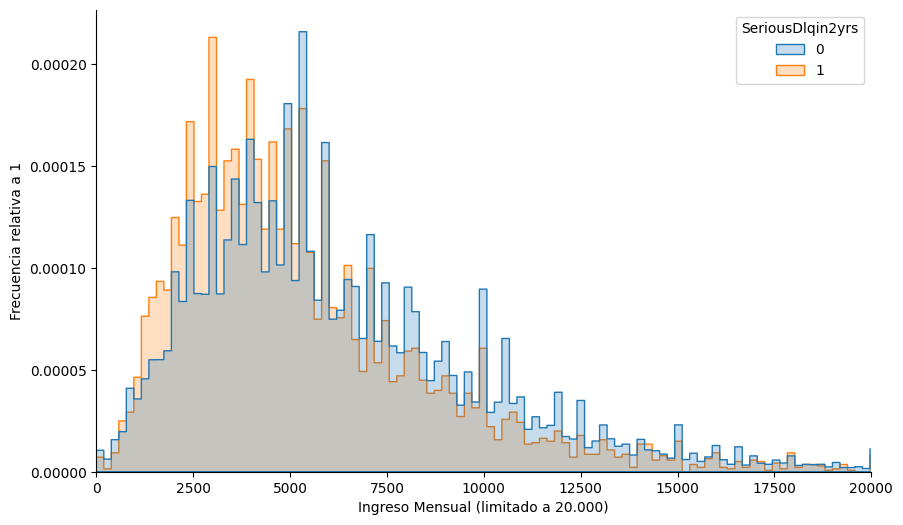

In [21]:
# Graficamos la distribución de ingresos para los distintos grupos en un mismo gráfico para que la comparación sea más fácil.

# Creamos el gráfico
plt.figure(figsize=(10, 6))

# Usamos 'hue' para separar por la columna de impago
sns.histplot(data=df, x='MonthlyIncome', stat="density", common_norm=False, hue='SeriousDlqin2yrs', kde=False, element="step")

# Limitamos el eje X si tienes ingresos muy altos (outliers) para que se vea bien
plt.xlim(0, 20000) 

#plt.title("Distribución de Ingresos: Buenos Pagadores vs Impagos", fontsize=14, fontweight="bold")
plt.xlabel("Ingreso Mensual (limitado a 20.000)")
plt.ylabel("Frecuencia relativa a 1")
# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("images/distribucion2.png", bbox_inches="tight", dpi=300)
plt.show()

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117362 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      117362 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  117362 non-null  float64
 2   age                                   117362 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  117362 non-null  int64  
 4   DebtRatio                             117362 non-null  float64
 5   MonthlyIncome                         117362 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       117362 non-null  int64  
 7   NumberOfTimes90DaysLate               117362 non-null  int64  
 8   NumberRealEstateLoansOrLines          117362 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  117362 non-null  int64  
 10  NumberOfDependents                    117362 non-null  float64
dtypes: fl

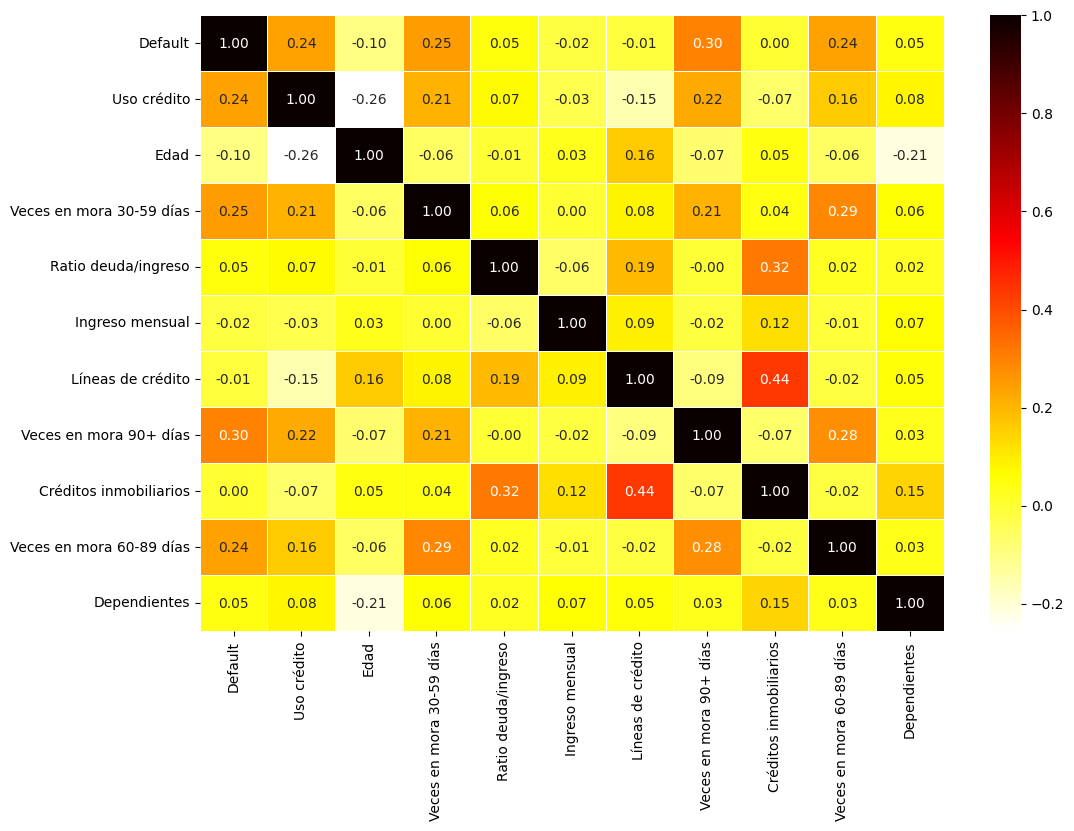

In [23]:
# Ahora mostraremos la matriz de correlaciones.
# Primero renombramos para que le gráfico quede lindo.
df_renamed = df.rename(columns={
    "SeriousDlqin2yrs": "Default",
    "RevolvingUtilizationOfUnsecuredLines": "Uso crédito",
    "age": "Edad",
    "NumberOfTime30-59DaysPastDueNotWorse": "Veces en mora 30-59 días",
    "DebtRatio": "Ratio deuda/ingreso",
    "MonthlyIncome": "Ingreso mensual",
    "NumberOfOpenCreditLinesAndLoans": "Líneas de crédito",
    "NumberOfTimes90DaysLate": "Veces en mora 90+ días",
    "NumberRealEstateLoansOrLines": "Créditos inmobiliarios",
    "NumberOfTime60-89DaysPastDueNotWorse": "Veces en mora 60-89 días",
    "NumberOfDependents": "Dependientes"
})


corr = df_renamed.corr()

# Graficamos.
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='hot_r', fmt=".2f", linewidths=0.5)

#plt.title("Mapa de Calor de Correlaciones", fontsize=14, fontweight="bold")
plt.savefig("images/correlaciones.png", bbox_inches="tight", dpi=300)
plt.show()

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117362 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      117362 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  117362 non-null  float64
 2   age                                   117362 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  117362 non-null  int64  
 4   DebtRatio                             117362 non-null  float64
 5   MonthlyIncome                         117362 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       117362 non-null  int64  
 7   NumberOfTimes90DaysLate               117362 non-null  int64  
 8   NumberRealEstateLoansOrLines          117362 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  117362 non-null  int64  
 10  NumberOfDependents                    117362 non-null  float64
dtypes: fl

# Regresión Logística

In [25]:
# Preparamos el set de datos.
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

# Dividimos el set de entrenamiento.
# Aquí hay un detalle importante y es que al trabajar con kagglehub se entregan 2 bases de datos, una de train y una de test
# Sin embargo la base de test no cuenta con los resultados para evaluar el modelo. Esto se hace para poder hacer competencias justas y reales.
# Por lo tanto en trabajos de práctica de debe evaluar el modelo con los datos de train.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Creamos y entrenamos el modelo.
modelo = LogisticRegression(max_iter=10000)
modelo.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [26]:
# Mostramos los tamaños de los grupos.
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(93889, 10)
(23473, 10)
(93889,)
(23473,)


In [27]:
# Ahora hacemos las predicciones.
# Primero debolvemos un array con las predicciones.
# EL otro array dice con qué probabilidad se hacen esas predicciones, poniendo el límite en la mitad.
# Sin embargo este límite puede cambiarse de acuerdo a los riesgos que el banco esté dispuesto a tomar.

predicciones = modelo.predict(X_test)
probabilidades = modelo.predict_proba(X_test)[:, 1]

Si $P(\text{impago}) \geq 0.5 \rightarrow$ Clasifica como 1 (Riesgo).

Si $P(\text{impago}) < 0.5 \rightarrow$ Clasifica como 0 (Seguro).

In [28]:
# Evaluamos el desempeño.

print("Matriz de Confusión")
print(confusion_matrix(y_test, predicciones))

"""
Para que se entienda esta matriz: es una matriz de errores.
       | predicho 0 | predicho 1  |
real 0 |____________|_____________|
real 1 |            |             |

Entonces. De todos los que no iban a pagar, se clasificó correctamente a 21879, mientras que a 146 se los clasificó como que no iban a pagar
cuando en realidad sí iban a pagar.

Luego a los que iban a caer en morosidad, a 205 se los clasificó correctamente, pero a 1243 no. Es decir que al modelo le está costando
encontrar a los que no pagarán, sin embargo encuentra bastante bien a los que sí pagarán.
"""

Matriz de Confusión
[[21878   147]
 [ 1243   205]]


'\nPara que se entienda esta matriz: es una matriz de errores.\n       | predicho 0 | predicho 1  |\nreal 0 |____________|_____________|\nreal 1 |            |             |\n\nEntonces. De todos los que no iban a pagar, se clasificó correctamente a 21879, mientras que a 146 se los clasificó como que no iban a pagar\ncuando en realidad sí iban a pagar.\n\nLuego a los que iban a caer en morosidad, a 205 se los clasificó correctamente, pero a 1243 no. Es decir que al modelo le está costando\nencontrar a los que no pagarán, sin embargo encuentra bastante bien a los que sí pagarán.\n'

In [29]:
# Mostramos los resultados

print("Reporte de Clasificación")
print(classification_report(y_test, predicciones))

# La precisión nos dice: De todos los que sí pagaron, a cuántos los asignamos correctamente? Es decir, a cuantos cleintes rechazamos innecesariamente.
# De todos los impagos, el modelo solo captuó al 14%.
# El F1 score es un promedio entre precisión y recall. Es muy útil cuando hay desbalance en los datos (como en este caso que los impagos son el 10%).

Reporte de Clasificación
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     22025
           1       0.58      0.14      0.23      1448

    accuracy                           0.94     23473
   macro avg       0.76      0.57      0.60     23473
weighted avg       0.92      0.94      0.92     23473



In [30]:
# El ROC AUC score es de:
# El ROC score nos dice qué tan útil es el modelo.
# Si es 0.5 es igual de útil que lanzar una moneda al aire.
# Si es de 1 el modelo es perfecto.
# Si es de 0 el modelo es terrible.
# Un modelo con un ROC AUC score de 0.83 es bastante bueno. Significa que el modelo predice correctamente con un 83% de probabilidad.
# La mejor nota en kaggle fue de 86.955%, por lo que los resultados de estas predicciones son increíblemente buenas.

print(f"ROC AUC Score: {roc_auc_score(y_test, probabilidades):.4f}")

ROC AUC Score: 0.8331


# Solución a bajo recall

In [31]:
# Supongamos que el banco es conservador.
# El recall es muy bajo, por lo que no estamos reconociendo a quienes nos pagan.
# Supongamos que al banco no le interesa tener tantos clientes, sino que los que tenga le paguen.
# (En realidad al banco le interesa maximizar la utilidad, no le importa la proporción de clientes, pero eso es una tarea más compleja).
# Aquí la simplificamos y queremos predecir mejor quiénes no pagarán.
# Lo que hacemos es bajar el umbral de decisión.
# Este umbral estaba en 0,5, lo bajamos a 0.3

In [32]:
# Lo único que tenemos que cambiar es que las nuevas predicciones se hacen bajo un nuevo umbral.
# El resto es lo mismo

probabilidades = modelo.predict_proba(X_test)[:, 1]
umbral = 0.3
nuevas_predicciones = (probabilidades >= umbral).astype(int)

In [33]:
print("Matriz de Confusión")
print(confusion_matrix(y_test, nuevas_predicciones))

Matriz de Confusión
[[21662   363]
 [ 1092   356]]


In [34]:
print("Reporte de Clasificación")
print(classification_report(y_test, nuevas_predicciones))

Reporte de Clasificación
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     22025
           1       0.50      0.25      0.33      1448

    accuracy                           0.94     23473
   macro avg       0.72      0.61      0.65     23473
weighted avg       0.92      0.94      0.93     23473



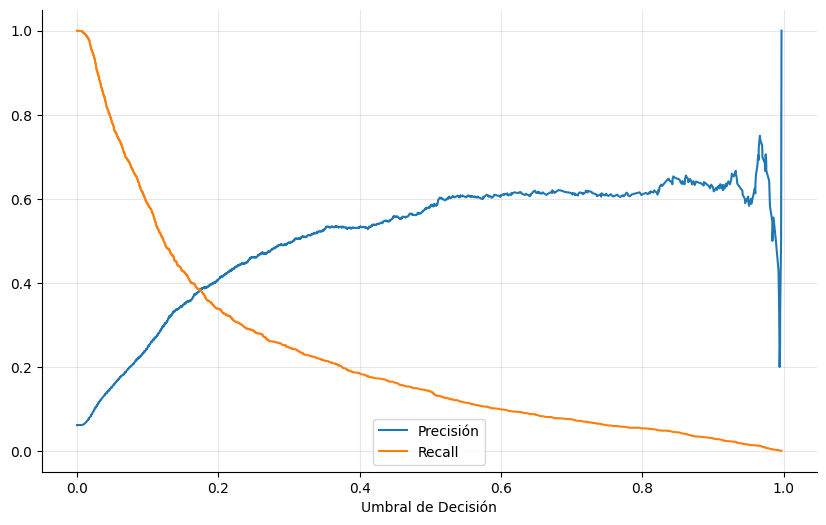

In [35]:
# Lo que hace este nuevo modelo es bajar el threshold. No espera a tener tanta seguridad para determinar si alguien será impago o no.
# Lo decide cuando la probabilidad supera el 0.3.
# La métrica de ROC AUC no cambia. Lo que sí cambia es la precisión-recall (hay siempre un trade-off).
# Podemos ver cómo cambia la precisión-recall para los distintos umbrales. 
# Esto nos puede llevar a determinar el umbral ideal. Ya que muchas veces el verdadero umbral óptimo es el resultado de una decisión 
# demasiado compleja.

precision, recall, thresholds = precision_recall_curve(y_test, probabilidades)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label="Precisión")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Umbral de Decisión")
#plt.title("Regresión logística - Relación entre Precisión y Recall según el Umbral")
plt.legend()
plt.grid(alpha=0.3)
# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("images/recall_precision.png", bbox_inches="tight", dpi=300)
plt.show()

# Random Forest

In [36]:
# Definimos los parámetros de un modelo de Random Forest.

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Ajustamos el modelo (No preocuparse si demora un poco).
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [37]:
# Hacemos las predicciones. Las predicciones y las probabilidades, siguiendo la misma lógica de antes.
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

In [38]:
# Evaluamos el modelo.

# Vemos que el modelo mejora un poquitín con random forest.

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     22025
           1       0.63      0.07      0.12      1448

    accuracy                           0.94     23473
   macro avg       0.79      0.53      0.55     23473
weighted avg       0.92      0.94      0.92     23473



In [39]:
print("Matriz de Confusión")
print(confusion_matrix(y_test, y_pred_rf))

Matriz de Confusión
[[21967    58]
 [ 1350    98]]


In [40]:
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

ROC-AUC: 0.8433356275202086


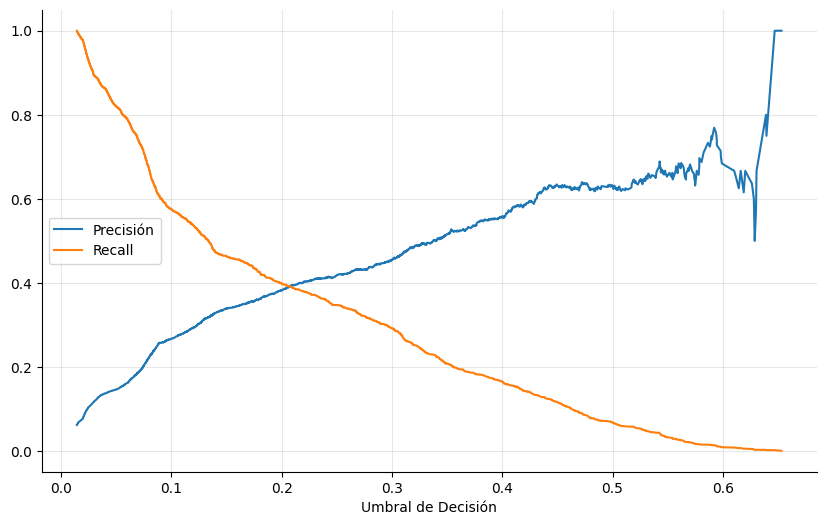

In [41]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_rf)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label="Precisión")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.xlabel("Umbral de Decisión")
#plt.title("Random Forest - Relación entre Precisión y Recall según el Umbral")
plt.legend()
plt.grid(alpha=0.3)
# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("images/randomforest.png", bbox_inches="tight", dpi=300)
plt.show()

In [42]:
# Random-forest mejora la capacidad predictiva entendiendo realaciones no lineales.
# El problema es que se pierde interpretabilidad.
# Sin embargo logistic regression permite tener impretabilidad todo el tiempo.
# Por lo tanto cada uno tiene sus ventajas en este análisis.
# Parece ser que por la poca mejora de logistic-regression------>random-forest lo mejor es utilizar logistic.

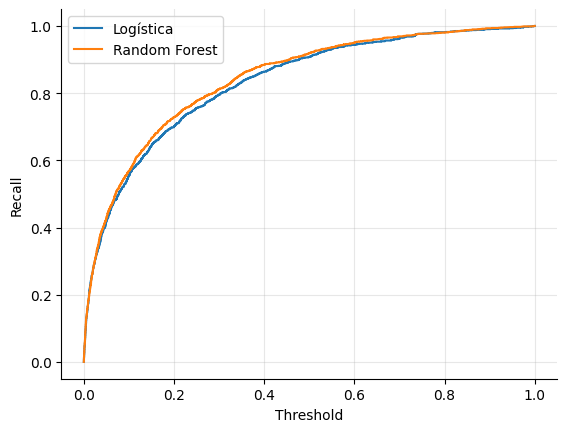

In [43]:
# Podemos comparar ROC AUC curve.

fpr_lr, tpr_lr, _ = roc_curve(y_test, probabilidades)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.plot(fpr_lr, tpr_lr, label="Logística")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.legend()
#plt.title("Curva ROC")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.grid(alpha=0.3)
# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("images/curvaROC.png", bbox_inches="tight", dpi=300)
plt.show()

# Poder explicativo de las variables. Random Forest.

In [44]:
importances = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

importances.head(10)

,feature,importance
6,NumberOfTimes90DaysLate,0.438287
8,NumberOfTime60-89DaysPastDueNotWorse,0.177785
0,RevolvingUtilizationOfUnsecuredLines,0.167293
2,NumberOfTime30-59DaysPastDueNotWorse,0.144121
3,DebtRatio,0.024740
1,age,0.016854
5,NumberOfOpenCreditLinesAndLoans,0.012455
4,MonthlyIncome,0.009350
7,NumberRealEstateLoansOrLines,0.006635
9,NumberOfDependents,0.002480


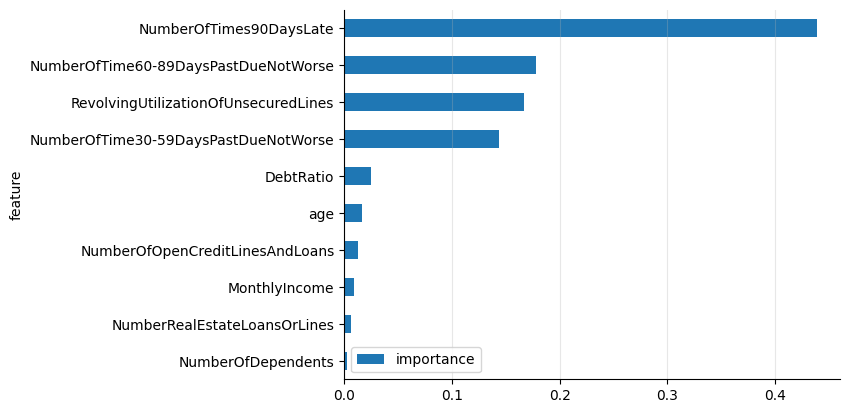

In [45]:
importances.head(10).plot(
    x="feature",
    y="importance",
    kind="barh"
)
plt.gca().invert_yaxis()
#plt.title("Importancia de variables")
plt.grid(axis="x", alpha=0.3)
# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("images/importancia_rf.png", bbox_inches="tight", dpi=300)
plt.show()

# Poder explicativo de las variables. Regresión logística.

In [46]:
# Notar como el modelo de regresión logística fue definido como "modelo".
# Los coeficientes aquí significan en qué sentido mueven la probabilidad del default.
# En random-forest solo se puede rankear la importancia, pero no entender el efecto de una variable en la probabilidad de default.

coef_df = pd.DataFrame({
    "variable": X.columns,
    "coef": modelo.coef_[0]
}).sort_values(by="coef", key=abs, ascending=False)

coef_df.head(10)

,variable,coef
0,RevolvingUtilizationOfUnsecuredLines,1.857592
6,NumberOfTimes90DaysLate,0.736959
8,NumberOfTime60-89DaysPastDueNotWorse,0.651226
2,NumberOfTime30-59DaysPastDueNotWorse,0.429340
3,DebtRatio,0.170284
7,NumberRealEstateLoansOrLines,0.101720
9,NumberOfDependents,0.044956
5,NumberOfOpenCreditLinesAndLoans,0.030657
1,age,-0.017709
4,MonthlyIncome,-0.000024


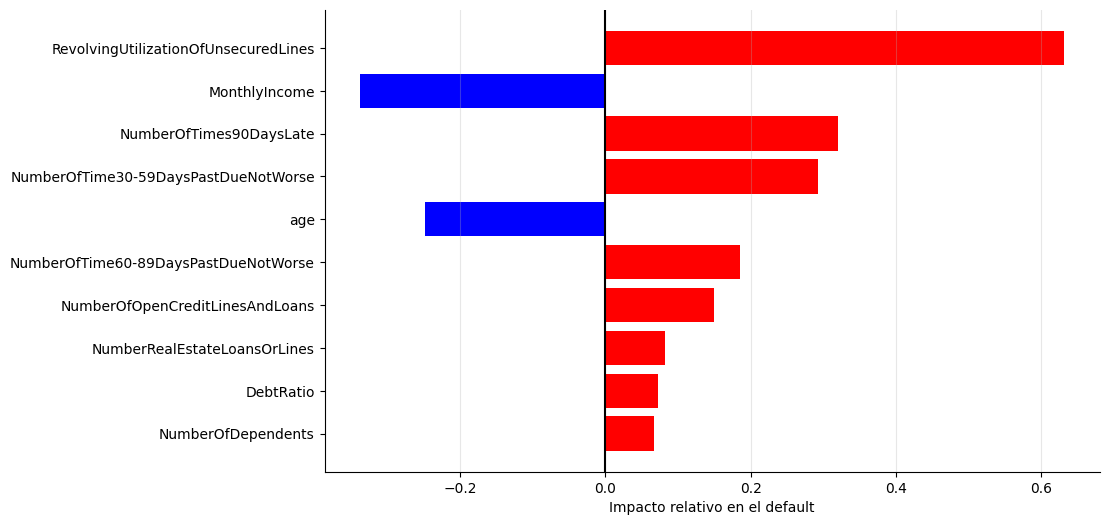

In [47]:
# Los coeficientes del modelo no son directamente comparablesdebido a que las variables están en distintas escalas.
# Por ello, se utiliza estandarización para analizar su importancia relativa.

# Así que haremos todo neuvamente reescalando las variables para que la interpretación tenga sentido.
# ===== 1. Guardar nombres de variables =====
# ===== 1. Definir variables =====
X = df.drop(columns=["SeriousDlqin2yrs"])
y = df["SeriousDlqin2yrs"]

# ===== 2. Train / Test split =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===== 3. Estandarizar (manteniendo DataFrame) =====
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

# ===== 4. Modelo (solo para interpretar coeficientes) =====
model_scaled = LogisticRegression(max_iter=1000)
model_scaled.fit(X_train_scaled, y_train)

# ===== 5. Coeficientes =====
coef_df_scaled = pd.DataFrame({
    "variable": X_train.columns,
    "coef": model_scaled.coef_[0]
})

# ===== 6. Ordenar por importancia =====
coef_df_scaled["abs_coef"] = coef_df_scaled["coef"].abs()
coef_df_scaled = coef_df_scaled.sort_values(by="abs_coef", ascending=False)

# ===== 7. Gráfico =====
plt.figure(figsize=(10,6))

colors = ["red" if x > 0 else "blue" for x in coef_df_scaled["coef"]]

plt.barh(coef_df_scaled["variable"], coef_df_scaled["coef"], color=colors)

plt.axvline(0, color="black")
plt.gca().invert_yaxis()

#plt.title("Importancia de variables (coeficientes estandarizados)", fontsize=14, fontweight="bold")
plt.xlabel("Impacto relativo en el default")
plt.grid(axis="x", alpha=0.3)
# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("images/importancia_lrbien.png", bbox_inches="tight", dpi=300)

plt.show()

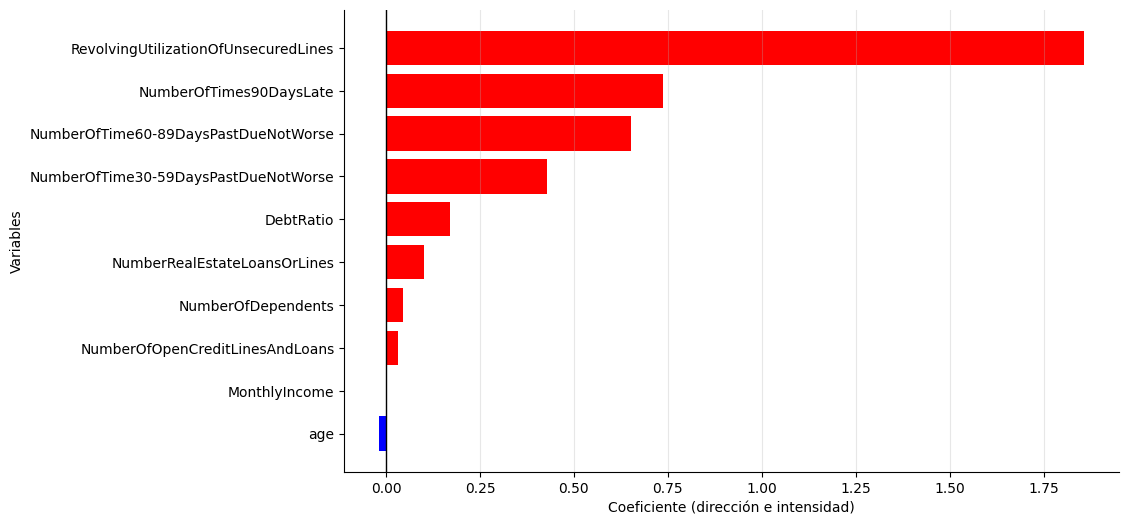

In [48]:
# Los coeficientes del modelo no son directamente comparablesdebido a que las variables están en distintas escalas.
# Por ello, se utiliza estandarización para analizar su importancia relativa.


plt.figure(figsize=(10, 6))

coef_df_sorted = coef_df.sort_values(by="coef")

colors = ["red" if x > 0 else "blue" for x in coef_df_sorted["coef"]]

plt.barh(coef_df_sorted["variable"], coef_df_sorted["coef"], color=colors)

plt.axvline(0, color="black", linewidth=1)

#plt.title("Impacto de las variables en el riesgo de default", fontsize=14, fontweight="bold")
plt.xlabel("Coeficiente (dirección e intensidad)")
plt.ylabel("Variables")
plt.grid(axis="x", alpha=0.3)
# Eliminar bordes
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("images/importancia_lrmal.png", bbox_inches="tight", dpi=300)
plt.show()

In [49]:
"""
El modelo permite identificar clientes con alto riesgo de default, destacando la importancia del historial de mora como principal predictor.
Este modelo podría utilizarse para mejorar decisiones de otorgamiento de crédito y reducir pérdidas.
Mientras que la regresión logística permite interpretar el efecto de cada variable, Random Forest mide su importancia en términos predictivos.
"""

'\nEl modelo permite identificar clientes con alto riesgo de default, destacando la importancia del historial de mora como principal predictor.\nEste modelo podría utilizarse para mejorar decisiones de otorgamiento de crédito y reducir pérdidas.\nMientras que la regresión logística permite interpretar el efecto de cada variable, Random Forest mide su importancia en términos predictivos.\n'